<a href="https://colab.research.google.com/github/Attri-Niharika/CEI-Assignments/blob/main/week6_niharika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
noise_factor = 0.4
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, 0.0, 1.0)
x_test_noisy = tf.clip_by_value(x_test_noisy, 0.0, 1.0)

In [4]:
latent_dim = 32

inputs = keras.Input(shape=(28, 28, 1))

x = keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(inputs)
x = keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)

x = keras.layers.Flatten()(x)
encoded = keras.layers.Dense(latent_dim, activation="relu")(x)

encoder = keras.Model(inputs, encoded, name="encoder")

decoder_input = keras.layers.Input(shape=(latent_dim,))
x = keras.layers.Dense(7 * 7 * 64, activation="relu")(decoder_input)
x = keras.layers.Reshape((7, 7, 64))(x)
x = keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoded = keras.layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(decoder_input, decoded, name="decoder")

autoencoder = keras.Model(inputs, decoder(encoder(inputs)), name="autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       119,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       159,169 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,369 (1.06 MB)

 Trainable params: 278,369 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test_noisy, x_test),
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0499 - val_loss: 0.0194
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0165 - val_loss: 0.0141
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0135 - val_loss: 0.0124
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0122 - val_loss: 0.0118
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0114 - val_loss: 0.0111


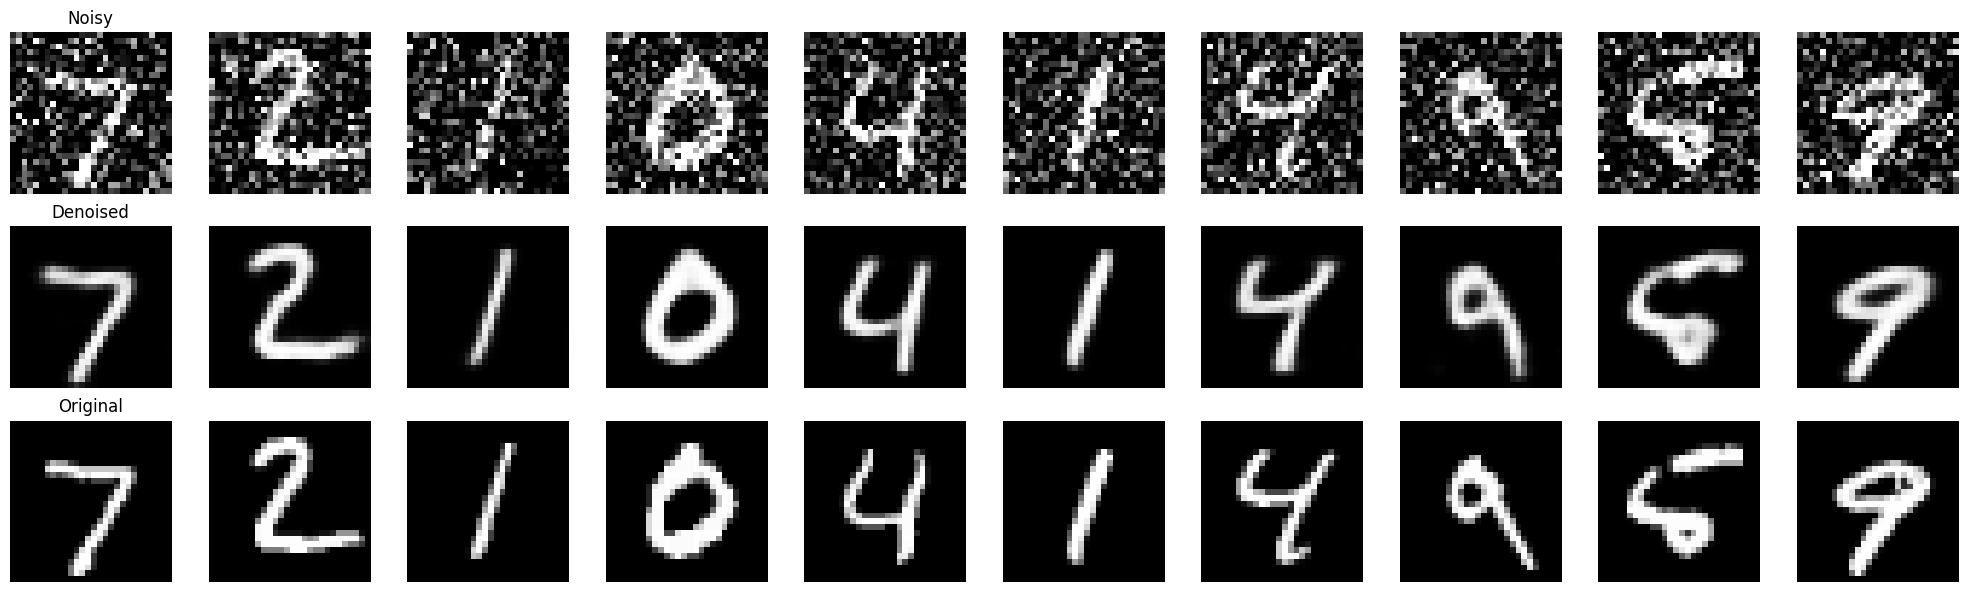

In [6]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].numpy().squeeze(), cmap="gray")
    ax.axis("off")
    if i == 0:
        ax.set_title("Noisy")

    ax = plt.subplot(3, n, i + 1 + n)
    preds = autoencoder.predict(x_test_noisy[i:i + 1], verbose=0)
    plt.imshow(preds.squeeze(), cmap="gray")
    ax.axis("off")
    if i == 0:
        ax.set_title("Denoised")

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    ax.axis("off")
    if i == 0:
        ax.set_title("Original")

plt.tight_layout()
plt.savefig("denoising_results.png")
plt.show()